<a href="https://colab.research.google.com/github/JustJess21/JesseE/blob/main/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

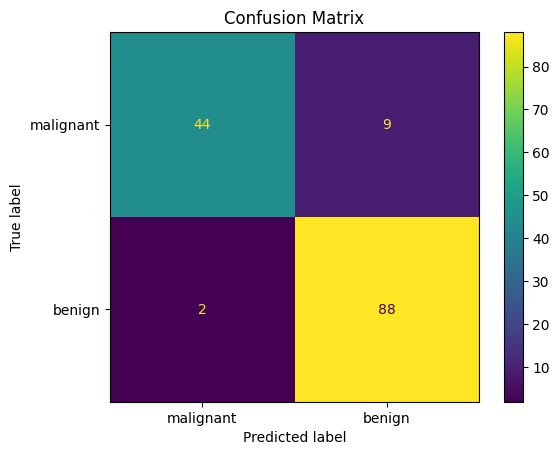


Classification Report:
               precision    recall  f1-score   support

   malignant       0.96      0.83      0.89        53
      benign       0.91      0.98      0.94        90

    accuracy                           0.92       143
   macro avg       0.93      0.90      0.92       143
weighted avg       0.93      0.92      0.92       143



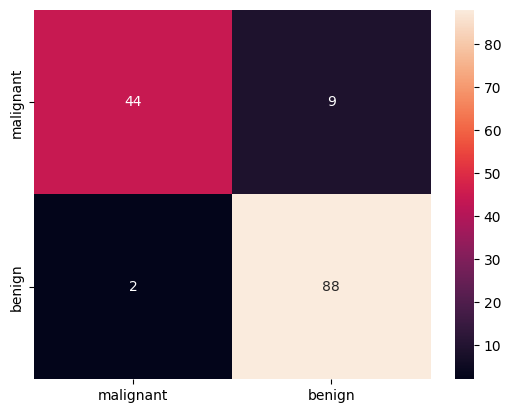


GNB Predictions: [1 0 1 0 0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1
 0 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 0
 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1]
Scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean Accuracy: 93.85%
Accuracy Standard Deviation: 2.75%
GaussianNB Accuracy: 93.85%
KNeighborsClassifier Accuracy: 92.79%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LogisticRegression Accuracy: 95.08%
SVC Accuracy: 91.92%


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()

print(cancer.DESCR)

print("\nSample size:", cancer.data.shape)
print("Target size:", cancer.target.shape)

print("\nFeature names:", cancer.feature_names)

print("\nTarget name:", cancer.target_names)

print("\nClass distribution:", np.bincount(cancer.target))

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=11, test_size=0.25, stratify=cancer.target)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


knn = KNeighborsClassifier()
knn.fit(X=X_train, y=y_train)
print("KNeighborsClassifier:", knn.score(X_test, y_test))

predicted = knn.predict(X=X_test)
expected = y_test
print("KNN Prediction:", predicted)
print("KNN Score:", f'{knn.score(X_test, y_test):.2%}')
confusion = confusion_matrix(y_true=expected, y_pred=predicted)
print("Confusion Matrix:", confusion)

names = [str(cancer.target_names[0]), str(cancer.target_names[1])]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=cancer.target_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(expected, predicted, target_names=names))

import pandas as pd
confusion_df = pd.DataFrame(confusion, index=names, columns=names)

import seaborn as sns
sns.heatmap(confusion_df, annot=True)
plt.show()

gnb = GaussianNB()
gnb.fit(X=X_train, y=y_train)
predicted = gnb.predict(X=X_test)
print("\nGNB Predictions:", predicted)

from sklearn.model_selection import KFold
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator=gnb, X=cancer.data, y=cancer.target, cv=kfold)
print(f'Scores: {scores}')
print(f'Mean Accuracy: {np.mean(scores):.2%}')
print(f'Accuracy Standard Deviation: {np.std(scores):.2%}')

estimators = [('GaussianNB', gnb), ('KNeighborsClassifier', KNeighborsClassifier()), ('LogisticRegression', LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000)), ('SVC', SVC(gamma='scale'))]
for name, model in estimators:
    scores = cross_val_score(estimator=model, X=cancer.data, y=cancer.target, cv=kfold)
    print(f'{name} Accuracy: {np.mean(scores):.2%}')
